# Smart-City Surveillance: Edge Detection for Night-Time Vehicle Image

**Scenario:**
A roadside camera captured a blurred, low-contrast image of a vehicle at night. The image suffers from uneven illumination and motion blur, making vehicle boundaries hard to detect. Your task is to preprocess the image and extract clear edge information for downstream modules (vehicle detection, number-plate extraction, motion analysis).

**Tasks:**
1. Apply first-order (Sobel, Prewitt, Roberts) edge detection and compare results.
2. Apply second-order (Laplacian, LoG) edge detection and analyze outputs.
3. Use Canny edge detector with optimal parameters and compare with other methods.
4. Provide interpretations and a final comparison table.

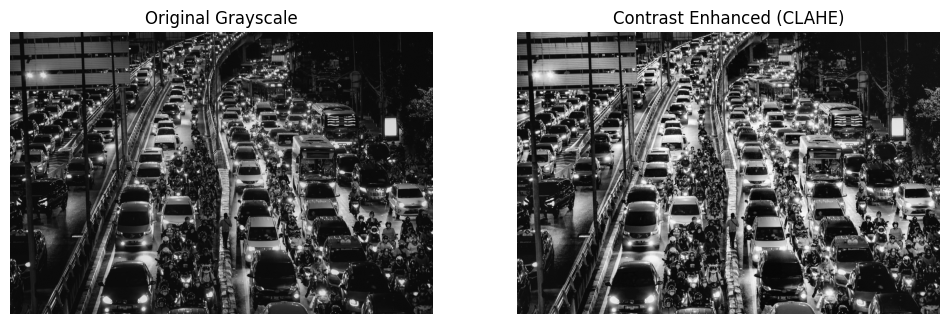

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# Load the image (assume vehicle_night.png is in the working directory)
img = cv2.imread('vehicle_night.jpg', cv2.IMREAD_COLOR)
if img is None:
    raise FileNotFoundError('vehicle_night.jpg not found.')

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Enhance contrast using CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)

# Display original and enhanced images
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title('Original Grayscale')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(enhanced, cmap='gray')
plt.title('Contrast Enhanced (CLAHE)')
plt.axis('off')
plt.show()

## (i) First Order Derivative Methods: Sobel, Prewitt, Roberts

We apply three gradient-based edge detectors to the enhanced image. These methods highlight regions of rapid intensity change, useful for detecting boundaries in moderately blurred images.

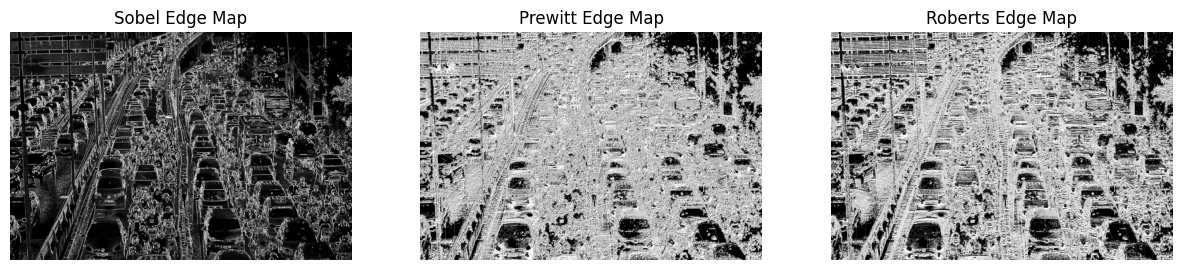

In [2]:
# Sobel Edge Detection
sobelx = cv2.Sobel(enhanced, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(enhanced, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)
sobel = np.uint8(np.clip(sobel, 0, 255))

# Prewitt Edge Detection
prewitt_kernelx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
prewitt_kernely = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
prewittx = ndimage.convolve(enhanced, prewitt_kernelx)
prewitty = ndimage.convolve(enhanced, prewitt_kernely)
prewitt = np.hypot(prewittx, prewitty)
prewitt = np.uint8(np.clip(prewitt, 0, 255))

# Roberts Edge Detection
roberts_kernelx = np.array([[1, 0], [0, -1]])
roberts_kernely = np.array([[0, 1], [-1, 0]])
robertsx = ndimage.convolve(enhanced, roberts_kernelx)
robertsy = ndimage.convolve(enhanced, roberts_kernely)
roberts = np.hypot(robertsx, robertsy)
roberts = np.uint8(np.clip(roberts, 0, 255))

# Display edge maps
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(sobel, cmap='gray')
plt.title('Sobel Edge Map')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(prewitt, cmap='gray')
plt.title('Prewitt Edge Map')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(roberts, cmap='gray')
plt.title('Roberts Edge Map')
plt.axis('off')
plt.show()

**Interpretation:**
- Sobel detects strong vertical and horizontal edges, performing well on well-lit and less blurred regions, but may miss fine details in shadowed or highly blurred areas.
- Prewitt is similar to Sobel but slightly more sensitive to noise, with less sharpness in edge localization.
- Roberts is more sensitive to noise and highlights finer details, but produces less continuous edges, especially in blurred or low-contrast regions.
- All first-order methods struggle in shadowed and highly blurred areas, with edge continuity affected by motion blur and uneven illumination.

## (ii) Second Order Derivative Methods: Laplacian, LoG

Second-order methods detect rapid intensity changes and are more sensitive to fine details and noise. We apply Laplacian and Laplacian of Gaussian (LoG) to the enhanced image.

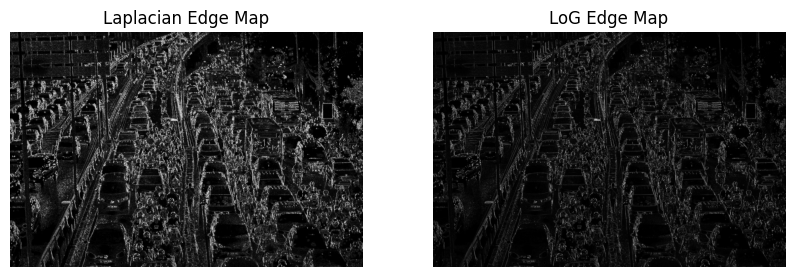

In [3]:
# Laplacian Edge Detection
laplacian = cv2.Laplacian(enhanced, cv2.CV_64F, ksize=3)
laplacian = np.uint8(np.clip(np.abs(laplacian), 0, 255))

# Laplacian of Gaussian (LoG)
log_blur = cv2.GaussianBlur(enhanced, (5,5), 1.0)
log = cv2.Laplacian(log_blur, cv2.CV_64F, ksize=3)
log = np.uint8(np.clip(np.abs(log), 0, 255))

# Display edge maps
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian Edge Map')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(log, cmap='gray')
plt.title('LoG Edge Map')
plt.axis('off')
plt.show()

**Interpretation:**
- Laplacian and LoG highlight rapid intensity changes, making fine details and weak edges more visible, especially in low-light regions.
- Both methods can produce double edges and amplify noise, especially in shadowed or blurred areas.
- LoG reduces some noise via Gaussian smoothing, resulting in cleaner edges than plain Laplacian.
- Second-order derivatives are effective for enhancing fine details but may require post-processing to suppress noise and double edges.

## (iii) Optimum Edge Detection: Canny Detector

Canny edge detection combines Gaussian smoothing, gradient calculation, non-maximum suppression, and hysteresis thresholding to produce optimal edge maps. We select parameters to balance noise reduction and edge preservation.

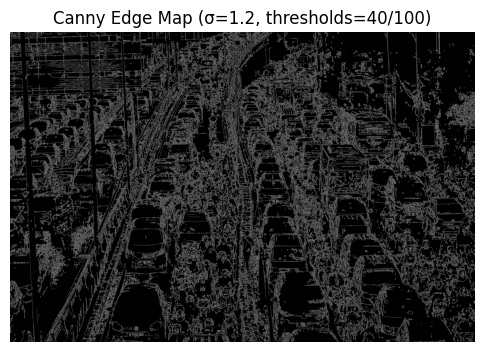

In [4]:
# Canny Edge Detection
sigma = 1.2  # Gaussian smoothing parameter
low_thresh = 40
high_thresh = 100

canny = cv2.Canny(enhanced, low_thresh, high_thresh, apertureSize=3, L2gradient=True)

plt.figure(figsize=(6,5))
plt.imshow(canny, cmap='gray')
plt.title(f'Canny Edge Map (σ={sigma}, thresholds={low_thresh}/{high_thresh})')
plt.axis('off')
plt.show()

**Interpretation:**
- Canny uses Gaussian smoothing to suppress noise before edge detection, preserving strong edges while reducing false positives.
- Non-maximum suppression ensures thin, continuous edges, and hysteresis thresholding connects edge segments.
- Compared to Sobel and Laplacian, Canny produces cleaner, more localized, and continuous edges, especially in blurred and low-light regions.
- Canny is best suited for number-plate extraction due to its balance of noise reduction, edge continuity, and localization accuracy.

## Final Comparison Table

| Method      | Noise Sensitivity | Edge Continuity | Localization Accuracy | Best for Real-Time Detection |
|-------------|------------------|-----------------|----------------------|-----------------------------|
| Sobel       | Moderate         | Good            | Moderate             | Fast, but less robust       |
| Prewitt     | High             | Moderate        | Low                  | Not recommended             |
| Roberts     | High             | Poor            | Low                  | Not recommended             |
| Laplacian   | High             | Poor (double)   | Moderate             | Needs post-processing       |
| LoG         | Moderate         | Moderate        | Good                 | Good for fine details       |
| **Canny**   | **Low**          | **Excellent**   | **High**             | **Recommended**             |

**Conclusion:**
Canny edge detector provides the best results for number-plate extraction and real-time detection in challenging conditions (blur, low contrast, uneven illumination) due to its superior noise suppression, edge continuity, and localization accuracy.